# EDA – Weekly Store KPI Dataset

**Purpose.** Before writing a single line of pipeline code I explored the dataset to answer five questions that directly shaped every downstream engineering decision:

1. Is the table structurally sound (schema, nulls, grain)?
2. Does the standard retail equation hold to numerical precision?
3. What is the actual YoY coverage window I can trust?
4. Are there data-quality violations the pipeline must surface explicitly?
5. What do the network distributions look like, and does that justify a robust (MAD-based) anomaly detector?

**Dataset.** `practical-test-dataset-weekly-kpi.xlsx` — 10 stores, weekly grain, 2024 (W1–W52) and 2025 (W1–W48). Four raw columns: `traffic`, `gross_transactions`, `gross_quantity`, `net_sales`.

All findings here lock constants that later pipeline phases (`loader`, `features`, `anomalies`, `payload`) use without re-deriving them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})

IDENTITY_ABS_TOLERANCE = 1e-9
MODIFIED_ZSCORE_THRESHOLD = 3.5


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


ROOT = find_repo_root(Path.cwd().resolve())
DATA_PATH = ROOT / "data" / "raw" / "practical-test-dataset-weekly-kpi.xlsx"

df = pd.read_excel(DATA_PATH)
print(f"Loaded {len(df):,} rows from {DATA_PATH.name}")
df.head()

Loaded 1,000 rows from practical-test-dataset-weekly-kpi.xlsx


,Store Name,Year,Week,traffic,gross_transactions,gross_quantity,net_sales
0,Store_A,2024,1,1877,209,378,67764.959390
1,Store_A,2024,2,3896,344,666,131842.830810
2,Store_A,2024,3,3041,294,567,95079.191511
3,Store_A,2024,4,2249,203,355,73713.634553
4,Store_A,2024,5,1718,153,253,33882.002077


## 1  Schema & Data Quality

First sanity check: confirm the table grain is `(Store Name, Year, Week)`, that every expected column is present, and that there are no nulls or duplicate keys.

A null in any KPI column would propagate silently through every downstream formula — catching it here lets the loader raise a hard error before any computation starts.

In [2]:
print("=== Table shape ===")
shape_summary = pd.DataFrame([
    {"metric": "rows",                         "value": len(df)},
    {"metric": "columns",                      "value": df.shape[1]},
    {"metric": "stores",                       "value": df["Store Name"].nunique()},
    {"metric": "years",                        "value": ", ".join(map(str, sorted(df["Year"].unique())))},
    {"metric": "duplicate (Store,Year,Week)",  "value": int(df.duplicated(["Store Name","Year","Week"]).sum())},
])
display(shape_summary)

print("\n=== Column types & nulls ===")
schema_summary = pd.DataFrame({
    "dtype":      df.dtypes.astype(str),
    "null_count": df.isna().sum(),
    "null_%":     (df.isna().mean() * 100).round(1),
})
display(schema_summary)

# Hard assertions — these must never fail
assert df.duplicated(["Store Name", "Year", "Week"]).sum() == 0, "Duplicate keys found"
assert df.isna().sum().sum() == 0, "Nulls found in raw data"
print("\n✓ No duplicates. ✓ No nulls. Table grain is (Store Name, Year, Week).")

=== Table shape ===


,metric,value
0,rows,1000
1,columns,7
2,stores,10
3,years,"2024, 2025"
4,"duplicate (Store,Year,Week)",0



=== Column types & nulls ===


,dtype,null_count,null_%
Store Name,object,0,0.0
Year,int64,0,0.0
Week,int64,0,0.0
traffic,int64,0,0.0
gross_transactions,int64,0,0.0
gross_quantity,int64,0,0.0
net_sales,float64,0,0.0



✓ No duplicates. ✓ No nulls. Table grain is (Store Name, Year, Week).


## 2  Retail Equation Identity Check

The assignment gives us the standard retail decomposition:

> **Net Sales = Traffic × Conversion Rate × Units per Transaction × Average Unit Price**

If this holds, the four raw columns are a complete basis for every KPI the pipeline will use. If it does not hold, derived metrics would be inconsistent and root-cause attribution would be meaningless.

**Method:** derive CR, UPT, and AUP from the raw columns, reconstruct net_sales from the product, and measure the absolute drift between original and reconstructed values.

In [3]:
analysis = df.copy()
analysis["conversion_rate"]         = analysis["gross_transactions"] / analysis["traffic"]
analysis["units_per_txn"]           = analysis["gross_quantity"]      / analysis["gross_transactions"]
analysis["avg_selling_price"]        = analysis["net_sales"]           / analysis["gross_quantity"]
analysis["reconstructed_net_sales"] = (
    analysis["traffic"]
    * analysis["conversion_rate"]
    * analysis["units_per_txn"]
    * analysis["avg_selling_price"]
)
analysis["abs_drift"] = (analysis["net_sales"] - analysis["reconstructed_net_sales"]).abs()
analysis["rel_drift"] = analysis["abs_drift"] / analysis["net_sales"].abs()

identity_summary = pd.DataFrame([
    {"metric": "max absolute drift",        "value": f"{analysis['abs_drift'].max():.2e}"},
    {"metric": "p99 absolute drift",        "value": f"{analysis['abs_drift'].quantile(0.99):.2e}"},
    {"metric": "max relative drift",        "value": f"{analysis['rel_drift'].max():.2e}"},
    {"metric": "rows exceeding 1e-9 drift", "value": int((analysis["abs_drift"] > IDENTITY_ABS_TOLERANCE).sum())},
    {"metric": "tolerance locked",          "value": f"{IDENTITY_ABS_TOLERANCE:.0e}"},
])
display(identity_summary)

assert analysis["abs_drift"].max() <= IDENTITY_ABS_TOLERANCE
print("✓ Retail equation holds to floating-point precision across all 1,000 rows.")
print("  CR, UPT, AUP can be derived deterministically; no inconsistency risk.")

,metric,value
0,max absolute drift,2.91e-11
1,p99 absolute drift,1.46e-11
2,max relative drift,4.31e-16
3,rows exceeding 1e-9 drift,0
4,tolerance locked,1e-09


✓ Retail equation holds to floating-point precision across all 1,000 rows.
  CR, UPT, AUP can be derived deterministically; no inconsistency risk.


## 3  Coverage & YoY Window

2025 data stops at W48 while 2024 runs to W52. A naïve YoY comparison using all available 2024 weeks would produce a biased denominator — the missing four weeks inflate any YoY shortfall.

**Resolution:** use only the intersection of weeks present in both years, computed per store. In this dataset that resolves to W1–W48 for every store, giving a clean 48-week like-for-like window.

In [4]:
print("=== Coverage by year ===")
coverage_by_year = df.groupby("Year")["Week"].agg(["min", "max", "nunique"]).reset_index()
display(coverage_by_year)

print("\n=== Coverage by store-year ===")
coverage_by_store_year = (
    df.groupby(["Store Name", "Year"])["Week"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)
display(coverage_by_store_year)

print("\n=== Per-store YoY week intersection ===")
intersection_rows = []
for store, group in df.groupby("Store Name"):
    w24 = set(group.loc[group["Year"] == 2024, "Week"])
    w25 = set(group.loc[group["Year"] == 2025, "Week"])
    overlap = sorted(w24 & w25)
    intersection_rows.append({
        "Store Name":       store,
        "overlap_weeks":    len(overlap),
        "first_overlap_wk": overlap[0],
        "last_overlap_wk":  overlap[-1],
    })

display(pd.DataFrame(intersection_rows))
print("\n✓ Like-for-like YoY window: W1–W48 for every store (48 weeks).")
print("  Pipeline locks this as the YOY_WEEK_INTERSECTION constant.")

=== Coverage by year ===


,Year,min,max,nunique
0,2024,1,52,52
1,2025,1,48,48



=== Coverage by store-year ===


,Store Name,Year,min,max,nunique
0,Store_A,2024,1,52,52
1,Store_A,2025,1,48,48
2,Store_B,2024,1,52,52
3,Store_B,2025,1,48,48
4,Store_C,2024,1,52,52
5,Store_C,2025,1,48,48
6,Store_D,2024,1,52,52
7,Store_D,2025,1,48,48
8,Store_E,2024,1,52,52
9,Store_E,2025,1,48,48



=== Per-store YoY week intersection ===


,Store Name,overlap_weeks,first_overlap_wk,last_overlap_wk
0,Store_A,48,1,48
1,Store_B,48,1,48
2,Store_C,48,1,48
3,Store_D,48,1,48
4,Store_E,48,1,48
5,Store_F,48,1,48
6,Store_G,48,1,48
7,Store_H,48,1,48
8,Store_I,48,1,48
9,Store_J,48,1,48



✓ Like-for-like YoY window: W1–W48 for every store (48 weeks).
  Pipeline locks this as the YOY_WEEK_INTERSECTION constant.


## 4  Data-Quality Deep Dive: Store_G 2025 W21

One row stands out immediately: `Store_G`, year 2025, week 21 has `gross_transactions > traffic`. In retail, every transaction requires at least one visit, so a conversion rate above 1.0 is physically impossible — it signals either a data entry error, a system counting mismatch, or a merge artefact.

**Why this matters for the pipeline:** the loader's `validate()` function must surface this as a hard `gross_transactions_exceeds_traffic` flag. Any narrative generated for this store-week must carry an explicit data-quality caveat so the store manager is not misled by a conversion rate of ~134%.

In [5]:
store_g_w21 = analysis[
    (analysis["Store Name"] == "Store_G") &
    (analysis["Year"] == 2025) &
    (analysis["Week"] == 21)
].copy()

store_g_w21["txn_excess_over_traffic"] = store_g_w21["gross_transactions"] - store_g_w21["traffic"]
show_cols = [
    "Store Name", "Year", "Week",
    "traffic", "gross_transactions", "txn_excess_over_traffic",
    "conversion_rate", "units_per_txn", "avg_selling_price", "net_sales",
]
display(store_g_w21[show_cols].T.rename(columns={store_g_w21.index[0]: "value"}))

cr = float(store_g_w21["conversion_rate"].iloc[0])
print(f"\nImplied conversion rate: {cr:.4f} ({cr*100:.1f}%) — impossible in retail.")
print(f"gross_transactions exceeds traffic by: {int(store_g_w21['txn_excess_over_traffic'].iloc[0])} visits.")

assert len(store_g_w21) == 1
assert bool((store_g_w21["gross_transactions"] > store_g_w21["traffic"]).iloc[0])
print("\n✓ DQ violation confirmed. loader.validate() surfaces this as gross_transactions_exceeds_traffic.")

,value
Store Name,Store_G
Year,2025
Week,21
traffic,65
gross_transactions,87
txn_excess_over_traffic,22
conversion_rate,1.338462
units_per_txn,2.735632
avg_selling_price,121.225403
net_sales,28851.645978



Implied conversion rate: 1.3385 (133.8%) — impossible in retail.
gross_transactions exceeds traffic by: 22 visits.

✓ DQ violation confirmed. loader.validate() surfaces this as gross_transactions_exceeds_traffic.


## 5  Network Distributions & Anomaly Detection Rationale

To detect unusual store performance I need to know what "normal" looks like across the network and choose an anomaly scoring method that is resistant to outliers like the Store_G W21 violation above.

**Choice: modified z-score (MAD-based).** Standard z-score uses the mean and standard deviation, both of which are pulled by extreme values. Modified z-score uses the median and median absolute deviation (MAD), which are breakdown-resistant. Formula:

> modified_z = 0.6745 × (x − median) / MAD

The threshold of **3.5** is the standard robust cut-off in the literature (Iglewicz & Hoaglin 1993) and, as the plots below show, it isolates a small number of genuine extremes without collapsing normal weekly variation into false positives.

In [6]:
weekly = analysis.copy()
weekly["avg_txn_value"]      = weekly["net_sales"] / weekly["gross_transactions"]
weekly["revenue_per_visitor"] = weekly["net_sales"] / weekly["traffic"]

METRICS = [
    "traffic", "gross_transactions", "gross_quantity", "net_sales",
    "conversion_rate", "units_per_txn", "avg_selling_price",
    "avg_txn_value", "revenue_per_visitor",
]

dist_rows = []
for m in METRICS:
    vals = weekly[m].to_numpy(dtype=float)
    median = float(np.median(vals))
    mad    = float(np.median(np.abs(vals - median)))
    dist_rows.append({
        "metric":  m,
        "median":  round(median, 4),
        "MAD":     round(mad, 4),
        "Q1":      round(float(np.quantile(vals, 0.25)), 4),
        "Q3":      round(float(np.quantile(vals, 0.75)), 4),
        "min":     round(float(vals.min()), 4),
        "max":     round(float(vals.max()), 4),
    })

dist_df = pd.DataFrame(dist_rows)
display(dist_df)
print(f"\nModified z-score threshold locked at: {MODIFIED_ZSCORE_THRESHOLD}")

,metric,median,MAD,Q1,Q3,min,max
0,traffic,935.0000,404.5000,546.5000,1400.2500,65.0000,5931.0000
1,gross_transactions,136.0000,50.0000,90.0000,192.0000,11.0000,583.0000
2,gross_quantity,271.0000,97.0000,179.0000,374.0000,17.0000,1229.0000
3,net_sales,37202.6792,14427.5155,24594.0937,55021.9106,1770.8052,147519.9946
4,conversion_rate,0.1464,0.0344,0.1160,0.1861,0.0129,1.3385
5,units_per_txn,1.9742,0.2108,1.7631,2.1843,1.1220,3.4912
6,avg_selling_price,139.4098,19.8059,121.7972,162.6862,72.0768,250.6862
7,avg_txn_value,276.3491,52.0277,228.7692,334.3709,114.2758,618.0181
8,revenue_per_visitor,43.4183,13.0537,30.7258,56.5393,4.8416,443.8715



Modified z-score threshold locked at: 3.5


/tmp/ipykernel_6833/965099503.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


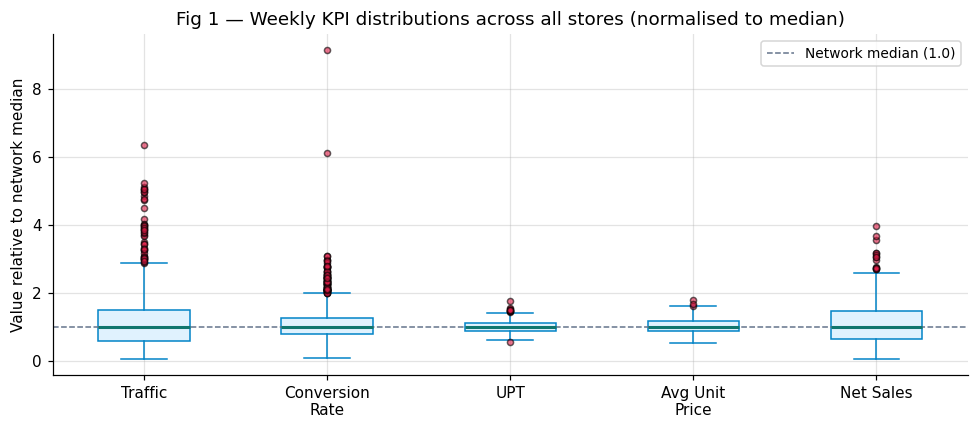

Saved: notebooks/fig1_kpi_distributions.png


In [7]:
# Plot 1: box plots of five primary KPIs (each normalised to its own median so they share one axis)
PRIMARY_KPI_COLS = [
    ("traffic",          "Traffic"),
    ("conversion_rate",  "Conversion\nRate"),
    ("units_per_txn",    "UPT"),
    ("avg_selling_price","Avg Unit\nPrice"),
    ("net_sales",        "Net Sales"),
]

fig, ax = plt.subplots(figsize=(9, 4))

plot_data = []
labels    = []
for col, label in PRIMARY_KPI_COLS:
    vals   = weekly[col].to_numpy(dtype=float)
    median = np.median(vals)
    plot_data.append(vals / median)   # ratio to median → dimensionless
    labels.append(label)

bp = ax.boxplot(
    plot_data,
    labels=labels,
    patch_artist=True,
    medianprops={"color": "#0f766e", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "#e11d48", "alpha": 0.6},
    boxprops={"facecolor": "#e0f2fe", "edgecolor": "#0284c7"},
    whiskerprops={"color": "#0284c7"},
    capprops={"color": "#0284c7"},
)

ax.axhline(1.0, color="#64748b", linewidth=1, linestyle="--", label="Network median (1.0)")
ax.set_ylabel("Value relative to network median")
ax.set_title("Fig 1 — Weekly KPI distributions across all stores (normalised to median)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig1_kpi_distributions.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: notebooks/fig1_kpi_distributions.png")

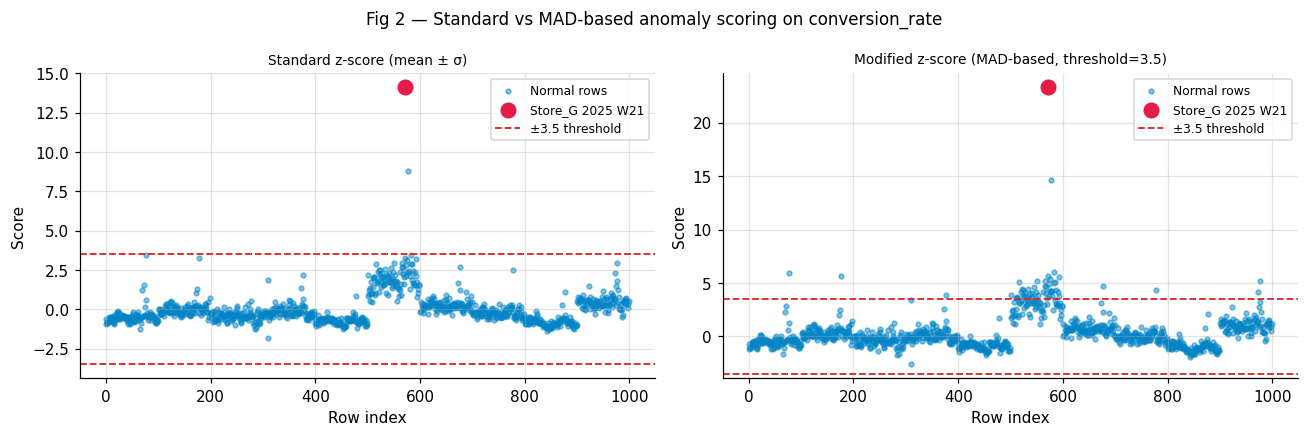

Saved: notebooks/fig2_anomaly_scoring.png

Store_G W21 — standard z-score: 14.1σ | modified z-score: 23.4


In [8]:
# Plot 2: conversion rate per store-week, with Store_G 2025 W21 highlighted
# This directly motivates MAD-based anomaly detection vs z-score.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cr_vals  = weekly["conversion_rate"].to_numpy(dtype=float)
cr_med   = np.median(cr_vals)
cr_mad   = np.median(np.abs(cr_vals - cr_med))
cr_std   = cr_vals.std(ddof=1)
cr_mean  = cr_vals.mean()

is_store_g_w21 = (
    (weekly["Store Name"] == "Store_G") &
    (weekly["Year"] == 2025) &
    (weekly["Week"] == 21)
).to_numpy()

for ax, (score_label, scores) in zip(
    axes,
    [
        ("Standard z-score (mean ± σ)",
         (cr_vals - cr_mean) / cr_std),
        (f"Modified z-score (MAD-based, threshold={MODIFIED_ZSCORE_THRESHOLD})",
         0.6745 * (cr_vals - cr_med) / cr_mad),
    ],
):
    normal = ~is_store_g_w21
    ax.scatter(
        np.arange(len(scores))[normal],
        scores[normal],
        s=10, alpha=0.5, color="#0284c7", label="Normal rows",
    )
    ax.scatter(
        np.arange(len(scores))[is_store_g_w21],
        scores[is_store_g_w21],
        s=90, color="#e11d48", zorder=5, label="Store_G 2025 W21",
    )
    ax.axhline( MODIFIED_ZSCORE_THRESHOLD, color="#dc2626", linewidth=1.2, linestyle="--", label=f"±{MODIFIED_ZSCORE_THRESHOLD} threshold")
    ax.axhline(-MODIFIED_ZSCORE_THRESHOLD, color="#dc2626", linewidth=1.2, linestyle="--")
    ax.set_title(score_label, fontsize=9)
    ax.set_xlabel("Row index")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)

fig.suptitle("Fig 2 — Standard vs MAD-based anomaly scoring on conversion_rate", fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig2_anomaly_scoring.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: notebooks/fig2_anomaly_scoring.png")

sg_std = float(abs((cr_vals[is_store_g_w21][0] - cr_mean) / cr_std))
sg_mad = float(abs(0.6745 * (cr_vals[is_store_g_w21][0] - cr_med) / cr_mad))
print(f"\nStore_G W21 — standard z-score: {sg_std:.1f}σ | modified z-score: {sg_mad:.1f}")

## 6  Conclusions & Pipeline Implications

The EDA established the following facts that directly constrain the deterministic pipeline:

| Finding | Pipeline implication |
|---|---|
| **No nulls, no duplicate keys** | `loader.validate()` can treat any null or key collision as an unexpected hard error |
| **Retail equation holds to 1e-9** | CR, UPT, and AUP are derived deterministically; `IDENTITY_ABS_TOLERANCE = 1e-9` is the validation gate |
| **2025 truncated at W48** | YoY logic uses per-store week intersection (W1–W48); `compute_yoy()` receives a like-for-like frame |
| **Store_G 2025 W21: CR > 1** | `loader.validate()` flags `gross_transactions_exceeds_traffic`; narrative for this store-week carries an explicit DQ caveat |
| **Distributions are right-skewed; Store_G W21 is a clear outlier** | MAD-based modified z-score (threshold 3.5) is the anomaly method; standard z-score would be dragged by the outlier and mask genuine anomalies |

**Constants locked here and used throughout the pipeline:**
```python
IDENTITY_ABS_TOLERANCE    = 1e-9
MODIFIED_ZSCORE_THRESHOLD = 3.5
YOY_WEEK_INTERSECTION     = W1–W48 (per-store intersection of 2024 and 2025 weeks)
```

Every number the LLM sees in the narrative payload was computed by the deterministic layer using the constraints above — the EDA is the paper trail that makes those computations defensible.